### Multimodal RAG (PDF With Images)

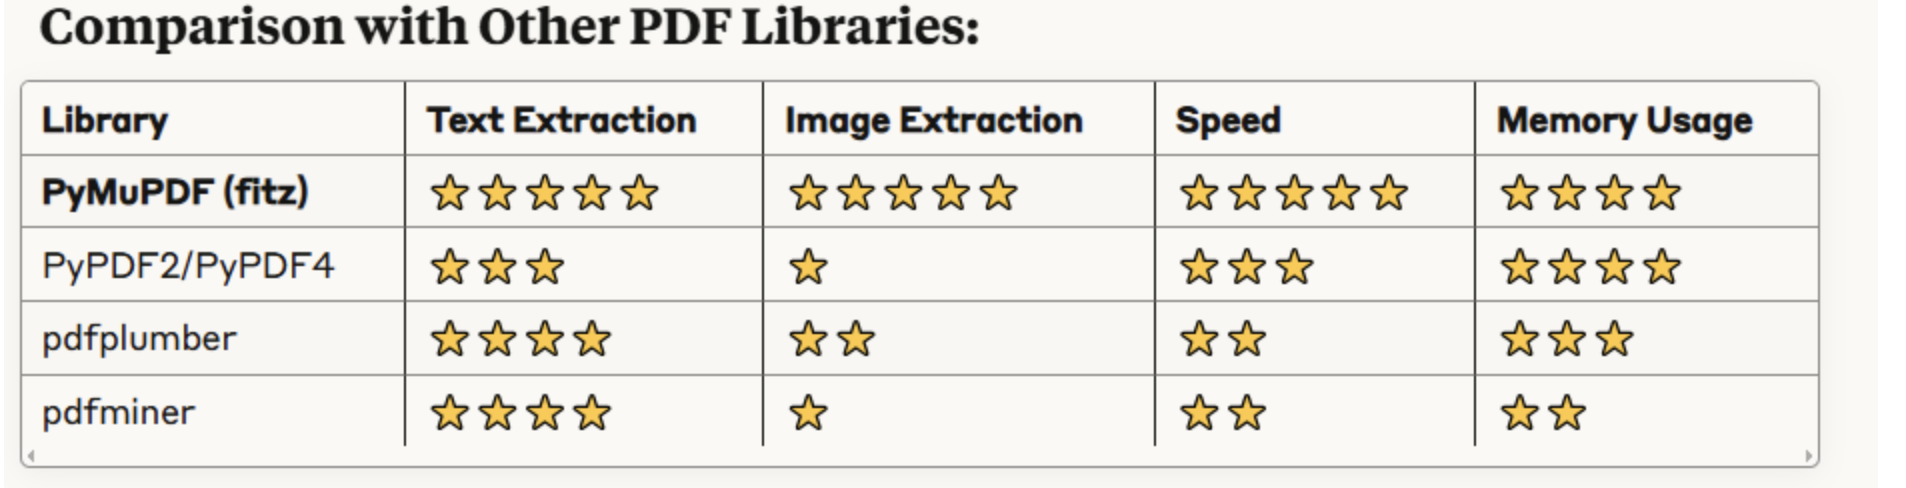

In [6]:
import fitz
from langchain_core.documents import Document
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import numpy as np
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from sklearn.metrics.pairwise import cosine_similarity
import os
import base64
import io
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [7]:
## Clip Model
from dotenv import load_dotenv
load_dotenv()

## Set up the environment
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

## initialize the Clip Model for unified text and image embeddings
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_model.eval()

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 30479.52it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [32]:
### Embedding functions
def embed_image(image_data):
    """Embed image data using the CLIP model."""
    if isinstance(image_data, str):         # If path
        image = Image.open(image_data).convert("RGB")
    else:   # If PIL Image
        image = image_data
    
    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = clip_model.get_image_features(**inputs)

        # Extract raw tensor from the Hugging Face output wrapper
        if hasattr(outputs, "pooler_output"):
            features = outputs.pooler_output
        elif hasattr(outputs, "image_embeds"):
            features = outputs.image_embeds
        else:
            features = outputs
        # Normalize embeddings to unit vector
        features = features / features.norm(dim=-1, keepdim=True)
        return features.squeeze().numpy()
    
def embed_text(text):
    """Embed text using the CLIP model."""
    inputs = clip_processor(
        text=text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77       # CLIP's max token length
    )
    with torch.no_grad():
        outputs = clip_model.get_text_features(**inputs)

        # Extract raw tensor from the Hugging Face output wrapper
        if hasattr(outputs, "pooler_output"):
            features = outputs.pooler_output
        elif hasattr(outputs, "text_embeds"):
            features = outputs.text_embeds
        else:
            features = outputs
                    
        # Normlize embeddings
        features = features / features.norm(dim=-1, keepdim=True)
        return features.squeeze().cpu().numpy()
    

In [33]:
## Process PDF and extract text and images

pdf_path = "multimodal_sample.pdf"
doc=fitz.open(pdf_path)

# Storage for all documents and embeddings
all_docs = []
all_embeddings = []
image_data_store = {}  # To store image data for later retrieval

# Text splitter for chunking text
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)



In [34]:
doc

Document('multimodal_sample.pdf')

In [35]:
for i,page in enumerate(doc):
    ## process text
    text=page.get_text()
    if text.strip():
        ## create temprary document for splitting
        temp_doc = Document(page_content=text, metadata={"page": i, "type": "text"})
        text_chunks = splitter.split_documents([temp_doc])

        #Embed each chunk using CLIP
        for chunk in text_chunks:
            embedding = embed_text(chunk.page_content)
            all_docs.append(chunk)
            all_embeddings.append(embedding)

    ## process images

    ## Three Important Actions:

    ## 1. Convert PDF image to PIL Image
    ## 2. Store as base64 for GPT-4V (Which needs base64 images)
    ## 3. Create CLIP embedding for the image and store it for retrieval
    for img_index, img in enumerate(page.get_images(full=True)):
        try:
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]

            # Convert bytes to PIL Image
            pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

            # Create unique identifier
            image_id = f"page_{i}_img_{img_index}"

            # Store image as base64 for later use with GPT-4V
            buffered = io.BytesIO()
            pil_image.save(buffered, format="PNG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode()
            image_data_store[image_id] = img_base64

            # Embed image using CLIP
            embedding = embed_image(pil_image)
            all_embeddings.append(embedding)

            # Create a document for the image with metadata
            image_doc = Document(
                page_content=f"[Image: {image_id}]",
                metadata={"page": i, "type": "image", "image_id": image_id}
            )
            all_docs.append(image_doc)

        except Exception as e:
            print(f"Error processing image {img_index} on page {i}: {e}")
            continue

doc.close()

In [36]:
all_embeddings

[array([-2.67237681e-03,  1.28299315e-02, -5.18315509e-02,  4.14879397e-02,
        -2.33942140e-02, -7.55863078e-03, -3.67659330e-02,  1.19710676e-01,
         8.52081701e-02,  2.05425452e-03, -1.11533813e-02, -1.29591990e-02,
         5.25014363e-02, -3.65394866e-03,  4.76078093e-02,  1.58373564e-02,
         2.03388203e-02,  4.35361937e-02, -3.29176104e-03,  2.03180518e-02,
         1.88016938e-03, -4.23493460e-02,  5.44094667e-03,  3.70935015e-02,
        -1.65622700e-02,  6.48643775e-03, -4.78011854e-02,  8.67476966e-03,
         5.88859543e-02, -3.21393944e-02,  4.32439744e-02,  9.65303089e-03,
        -4.47919173e-03, -1.94857009e-02, -3.63502875e-02, -1.23472288e-02,
        -2.17928961e-02, -1.99016426e-02,  8.09620842e-02, -3.32987234e-02,
        -2.38900203e-02, -3.96138951e-02, -1.27279852e-02,  3.50380130e-02,
        -2.52217390e-02,  2.00028089e-03,  1.49661032e-02, -2.31977347e-02,
        -6.86792284e-02, -5.25781943e-04, -2.22545397e-02, -1.04103982e-02,
        -1.9

In [37]:
all_docs

[Document(metadata={'page': 0, 'type': 'text'}, page_content='Annual Revenue Overview\nThis document summarizes the revenue trends across Q1, Q2, and Q3. As illustrated in the chart\nbelow, revenue grew steadily with the highest growth recorded in Q3.\nQ1 showed a moderate increase in revenue as new product lines were introduced. Q2 outperformed\nQ1 due to marketing campaigns. Q3 had exponential growth due to global expansion.'),
 Document(metadata={'page': 0, 'type': 'image', 'image_id': 'page_0_img_0'}, page_content='[Image: page_0_img_0]')]

In [38]:
# Create unified FAISS vector store with CLIP embeddings
embeddings_array = np.array(all_embeddings)
embeddings_array

array([[-0.00267238,  0.01282993, -0.05183155, ..., -0.00385087,
         0.02977716, -0.00010691],
       [ 0.01732348, -0.01327703, -0.02427021, ...,  0.08993986,
        -0.00272148,  0.03253056]], shape=(2, 512), dtype=float32)

In [39]:
# Create custom FAISS index since we have precomputed embeddings
vector_store = FAISS.from_embeddings(
    text_embeddings=[(doc.page_content, emb) for doc, emb in zip(all_docs, all_embeddings)],
    embedding=None,         # We're using precomputed embeddings
    metadatas=[doc.metadata for doc in all_docs]
)

vector_store

`embedding_function` is expected to be an Embeddings object, support for passing in a function will soon be removed.


In [40]:
# Initialize GPT-4 Vision model
llm = init_chat_model("openai:gpt-4.1")
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x16048a3f0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x1609783e0>, root_client=<openai.OpenAI object at 0x15f1bed20>, root_async_client=<openai.AsyncOpenAI object at 0x16048a480>, model_name='gpt-4.1', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [41]:
def retrieve_multimodal(query, k=5):
    """Unified retrieval using CLIP embeddings for both text and images."""
    # Embed query using CLIP
    query_embedding = embed_text(query)

    # Search in unified vector store
    results = vector_store.similarity_search_by_vector(
        embedding=query_embedding,
        k=k
    )

    return results

In [42]:
def create_multimodal_message(query, retrieved_docs):
    """Create a message with both text and images for GPT-4V"""
    content = []

    #Add the query
    content.append({
        "type": "text",
        "text": f"Question: {query}\n\nContext:\n"
    })

    # Separate text and image documents
    text_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "text"]
    image_docs = [doc for doc in retrieved_docs if doc.metadata.get("type") == "image"]

    # Add text context
    if text_docs:
        text_context = "\n\n".join([
            f"[Page {doc.metadata['page']}]: {doc.page_content}"
            for doc in text_docs
        ])
        content.append({
            "type": "text",
            "text": f"Text excerpts:\n{text_context}\n"
        })

    # Add image context
    for doc in image_docs:
        image_id = doc.metadata.get("image_id")
        if image_id and image_id in image_data_store:
            content.append({
                "type": "text",
                "text": f"\n[Image from page {doc.metadata['page']}]:\n"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image_data_store[image_id]}"
                }
            })

    # Add instruction
    content.append({
        "type": "text",
        "text": "\nPlease answer the question based on the provided text and images."
    })

    return HumanMessage(content=content)

In [43]:
def multimodal_pdf_rag_pipeline(query):
    """Main pipeline for multimodal RAG"""

    # Retrieve relevant documents
    context_docs = retrieve_multimodal(query=query, k=5)

    # Create multimodal message for GPT-4V
    message = create_multimodal_message(query, context_docs)

    # Get response from GPT-4V
    response = llm.invoke([message])

    # Print retrieved context info
    print(f"\nRetrieved {len(context_docs)} documents:")
    for doc in context_docs:
        doc_type = doc.metadata.get("type", "unknown")
        page = doc.metadata.get("page", "N/A")
        if doc_type == "text":
            preview = doc.page_content[:100] + "..." if len(doc.page_content) > 100 else doc.page_content
            print(f"- Text from Page {page}: {preview}")
        else:
            print(f"- Image from Page {page}")

    return response.content

In [44]:
if __name__ == "__main__":
    # Example queries
    queries = [
        "What does the chart on page 1 show about revenue trends?",
        "Summarize the main findings from the document",
        "What visual elements are present in the document?"
    ]

    for query in queries:
        print(f"\nQuery: {query}")
        print("-" * 50)
        answer = multimodal_pdf_rag_pipeline(query)
        print(f"\nAnswer:\n{answer}")
        print("=" * 50)


Query: What does the chart on page 1 show about revenue trends?
--------------------------------------------------

Retrieved 2 documents:
- Text from Page 0: Annual Revenue Overview
This document summarizes the revenue trends across Q1, Q2, and Q3. As illust...
- Image from Page 0

Answer:
The chart on page 1 shows that revenue increased steadily over the three quarters. 

- In Q1 (represented by the blue bar), revenue rose moderately, helped by new product launches.
- In Q2 (green bar), revenue was higher than Q1, mainly due to successful marketing campaigns.
- In Q3 (red bar), revenue growth accelerated sharply, showing the highest increase, which is attributed to global expansion.

Overall, the chart demonstrates a consistent upward trend in revenue, with the most significant growth in Q3.

Query: Summarize the main findings from the document
--------------------------------------------------

Retrieved 2 documents:
- Text from Page 0: Annual Revenue Overview
This document summari